In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective
from etl_pipeline_local import get_over_15_table

sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.INFO)

load_dotenv()

True

In [2]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate
# TODO: analisi  univariata KPI più promettenti (Optional)

# 1. Load Data

In [3]:
# Bet setup
target_col = "over_15"
odds_col: str = "over_15_odds"

# Load data
df_loaded = get_over_15_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df[odds_col] = 1.3
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
# df = df[df["underOver_quote_currentU"] <= 1.7]

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

## 2. Define Parameters

In [11]:
# Define features and relative step
# feature_bins_map = {
#  'underOver_chance_over15': 5,
#  'underOver_comparison_affini': 1000,
#  'underOver_comparison_flashback': 200,
#  'underOver_flashback_over15': 4,
#  'evaluation_valUnderOver': None
# }

feature_bins_map = {
'underOver_quote_initialU': 0.5,
 'underOver_flashback_over25': 5,
'underOver_flashback_under35': 5,
'underOver_flashback_over35': 5,
'underOver_flashback_under05HT': 5,
'underOver_flashback_over05HT': 5,
# 'underOver_bookkeeping_o': 5,
# 'underOver_comparison_flashback': 500
}

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 1, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: underOver_quote_initialU
Search space: [1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


Feature: underOver_flashback_over25
Search space: <IntegerArray>
[25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, <NA>]
Length: 15, dtype: Int64


Feature: underOver_flashback_under35
Search space: <IntegerArray>
[25, 30, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, <NA>]
Length: 14, dtype: Int64


Feature: underOver_flashback_over35
Search space: <IntegerArray>
[10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 75, <NA>]
Length: 14, dtype: Int64


Feature: underOver_flashback_under05HT
Search space: <IntegerArray>
[10, 15, 20, 25, 30, 35, 40, 45, 50, <NA>]
Length: 10, dtype: Int64


Feature: underOver_flashback_over05HT
Search space: <IntegerArray>
[50, 55, 60, 65, 70, 75, 80, 85, 90, <NA>]
Length: 10, dtype: Int64




## 3. Optimize

In [12]:
# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

[I 2026-04-10 16:51:14,080] A new study created in memory with name: no-name-e8d9cdc5-77f7-4dda-b9fd-3eef87d54a30
[I 2026-04-10 16:51:14,082] Trial 0 pruned. 
[I 2026-04-10 16:51:14,085] Trial 1 pruned. 
[I 2026-04-10 16:51:14,086] Trial 2 pruned. 
[I 2026-04-10 16:51:14,088] Trial 3 pruned. 
[I 2026-04-10 16:51:14,091] Trial 4 pruned. 
[I 2026-04-10 16:51:14,094] Trial 5 pruned. 
[I 2026-04-10 16:51:14,097] Trial 6 pruned. 
[I 2026-04-10 16:51:14,099] Trial 7 pruned. 
[I 2026-04-10 16:51:14,100] Trial 8 pruned. 
[I 2026-04-10 16:51:14,101] Trial 9 pruned. 
[I 2026-04-10 16:51:14,104] Trial 10 pruned. 
[I 2026-04-10 16:51:14,106] Trial 11 pruned. 
[I 2026-04-10 16:51:14,107] Trial 12 pruned. 
[I 2026-04-10 16:51:14,111] Trial 13 pruned. 
[I 2026-04-10 16:51:14,112] Trial 14 pruned. 
[I 2026-04-10 16:51:14,117] Trial 15 pruned. 
[I 2026-04-10 16:51:14,118] Trial 16 pruned. 
[I 2026-04-10 16:51:14,119] Trial 17 pruned. 
[I 2026-04-10 16:51:14,120] Trial 18 pruned. 
[I 2026-04-10 16:51:14

[FrozenTrial(number=429, state=<TrialState.COMPLETE: 1>, values=[2.2476820196653406], datetime_start=datetime.datetime(2026, 4, 10, 16, 51, 21, 914394), datetime_complete=datetime.datetime(2026, 4, 10, 16, 51, 21, 963809), params={'underOver_quote_initialU_use_min': True, 'underOver_quote_initialU_use_max': False, 'use_underOver_quote_initialU': True, 'underOver_quote_initialU_min': 2.0, 'underOver_quote_initialU_max': 3.5, 'underOver_flashback_over25_include_missing': False, 'underOver_flashback_over25_use_min': True, 'underOver_flashback_over25_use_max': True, 'use_underOver_flashback_over25': True, 'underOver_flashback_over25_min': 60, 'underOver_flashback_over25_max': 90, 'underOver_flashback_under35_include_missing': False, 'underOver_flashback_under35_use_min': True, 'underOver_flashback_under35_use_max': True, 'use_underOver_flashback_under35': False, 'underOver_flashback_under35_min': 50, 'underOver_flashback_under35_max': 55, 'underOver_flashback_over35_include_missing': False

## 4. Evaluate

In [13]:
best_trials[0].user_attrs["params_dict"]

{'underOver_quote_initialU_use_min': True,
 'underOver_quote_initialU_use_max': False,
 'use_underOver_quote_initialU': True,
 'underOver_quote_initialU_min': 2.0,
 'underOver_quote_initialU_max': 3.5,
 'underOver_flashback_over25_include_missing': False,
 'underOver_flashback_over25_use_min': True,
 'underOver_flashback_over25_use_max': True,
 'use_underOver_flashback_over25': True,
 'underOver_flashback_over25_min': 60,
 'underOver_flashback_over25_max': 90,
 'underOver_flashback_under35_include_missing': False,
 'underOver_flashback_under35_use_min': True,
 'underOver_flashback_under35_use_max': True,
 'use_underOver_flashback_under35': False,
 'underOver_flashback_under35_min': 50,
 'underOver_flashback_under35_max': 55,
 'underOver_flashback_over35_include_missing': False,
 'underOver_flashback_over35_use_min': False,
 'underOver_flashback_over35_use_max': True,
 'use_underOver_flashback_over35': True,
 'underOver_flashback_over35_min': 55,
 'underOver_flashback_over35_max': 60,
 

In [14]:
# Create the test binned dataframe
return_threshold = -3.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return 0.7000000000000008
Max return 19.600000000000005
Score 2.2476820196653406


Trial no. 1
Min return 0.7000000000000008
Max return 19.600000000000005
Score 2.2476820196653406


Trial no. 2
Min return 0.7000000000000008
Max return 19.600000000000005
Score 2.2476820196653406


Trial no. 5
Min return -0.3999999999999977
Max return 16.800000000000004
Score 2.0790368478459964


Trial no. 6
Min return -0.3999999999999977
Max return 15.900000000000004
Score 1.939737443069399


Trial no. 7
Min return -0.3999999999999977
Max return 15.900000000000004
Score 1.939737443069399


Trial no. 8
Min return -0.6999999999999977
Max return 15.900000000000004
Score 1.9353980244347762


Trial no. 9
Min return -0.6999999999999977
Max return 15.900000000000004
Score 1.9353980244347762




Mean Train ROI: 0.0949404761904762
Train Accuracy: 0.8 (1698/2016)
Mean Test ROI: 0.07924528301886796
Test Accuracy: 0.8 (396/477)


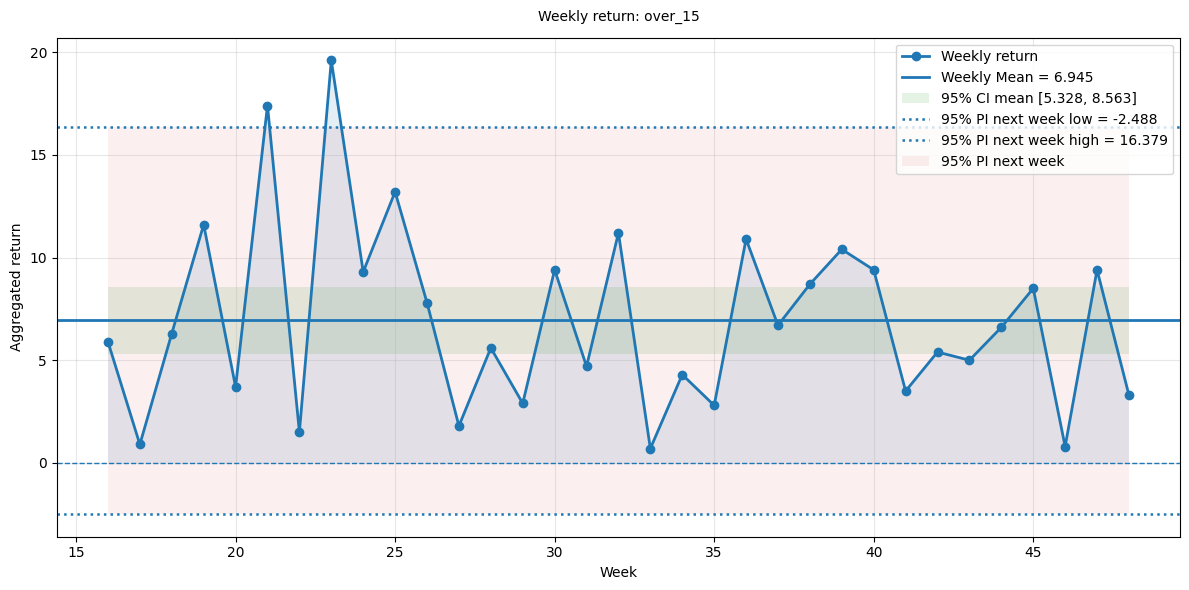

In [15]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [16]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 33/48 (0.69)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_15,6.95,4.56,51.94,48.12,2493,0.86


## 5. Save best Trials

In [ ]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

[I 2026-04-03 16:22:58,327] A new study created in RDB with name: over_15_aggregated_study


Aggiunti: 1
Totale trial archiviati: 1
Best assoluto: 2.428976876168547 {'underOver_chance_over15_use_min': True, 'underOver_chance_over15_use_max': True, 'underOver_chance_over15_min': 60, 'underOver_chance_over15_max': 90, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'underOver_comparison_affini_min': 3000, 'underOver_comparison_affini_max': 16000, 'underOver_comparison_flashback_use_min': False, 'underOver_comparison_flashback_use_max': True, 'underOver_comparison_flashback_min': 6000, 'underOver_comparison_flashback_max': 15000, 'underOver_flashback_over15_include_missing': False, 'underOver_flashback_over15_use_min': True, 'underOver_flashback_over15_use_max': False, 'underOver_flashback_over15_min': 76, 'underOver_flashback_over15_max': 92, 'evaluation_valUnderOver_cat_idx': 47}
